In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 1. Create the local directory
!mkdir -p /content/dataset

# 2. Extract the .tgz file into that folder
# -x: extract | -z: gzip | -f: file | -C: destination directory
!tar -xzf "/content/drive/MyDrive/FinalYearProject/Dataset/MultiModalDataset.tgz" -C /content/dataset

In [7]:
# Install the library
!pip install demoji

import demoji
import re

# Download the latest emoji descriptions database
demoji.download_codes()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.1 MB/s eta 0:00:00


/tmp/ipython-input-886243763.py:8: FutureWarning: The demoji.download_codes attribute is deprecated and will be removed from demoji in a future version. It is an unused attribute as emoji codes are now distributed directly with the demoji package.
  demoji.download_codes()


In [8]:
def clean_tweet_v2(text):
    if not text:
        return ""

    # 1. Emoji Preservation: Convert 😭 to " :loudly_crying_face: "
    # We use separators to ensure the description is treated as distinct words
    text = demoji.replace_with_desc(text, sep=" ")

    # 2. URL Removal: Strip out web links
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. HTML Artifacts: Remove things like &amp; or &lt;
    text = re.sub(r'&\w+;', '', text)

    # 4. Whitespace & Line Breaks: Flatten the tweet into one clean line
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Normalization: Lowercase everything
    return text.lower()

In [9]:
test_tweets = [
    "I feel so alone today... 😭 @mentalhealth_bot help me! http://support.com/help",
    "Feeling GREAT! 🌟 check this out at www.website.com #happy",
    "Why is everything so hard? &amp; I can't sleep. @user123 @user456",
    "Standard text with no noise."
]

print("--- PREPROCESSING TEST RESULTS ---\n")
for raw in test_tweets:
    cleaned = clean_tweet_v2(raw)
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}")
    print("-" * 30)

--- PREPROCESSING TEST RESULTS ---

RAW: I feel so alone today... 😭 @mentalhealth_bot help me! http://support.com/help
CLEANED: i feel so alone today... loudly crying face @mentalhealth_bot help me!
------------------------------
RAW: Feeling GREAT! 🌟 check this out at www.website.com #happy
CLEANED: feeling great! glowing star check this out at #happy
------------------------------
RAW: Why is everything so hard? &amp; I can't sleep. @user123 @user456
CLEANED: why is everything so hard? i can't sleep. @user123 @user456
------------------------------
RAW: Standard text with no noise.
CLEANED: standard text with no noise.
------------------------------


In [10]:
!pip install vaderSentiment

import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00


In [11]:
# -----------------------------
# Psycholinguistic Resources
# -----------------------------
FIRST_PERSON_SINGULAR = {
    "i", "me", "my", "mine", "i'm", "i’ve", "i'll", "i’d"
}

FIRST_PERSON_PLURAL = {
    "we", "us", "our", "ours", "we're", "we’ve", "we'll", "we’d"
}

sentiment_analyzer = SentimentIntensityAnalyzer()


def extract_psycholinguistic_features(user_path, max_tweets=50):
    timeline_path = os.path.join(user_path, "timeline.txt")
    if not os.path.exists(timeline_path):
        return None

    sentiments = []
    total_words = 0
    fps_count = 0
    fpp_count = 0
    mention_count = 0
    unique_mentions = set()
    tweet_count = 0
    media_count = 0

    image_ids = {
        os.path.splitext(f)[0]
        for f in os.listdir(user_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    }

    with open(timeline_path, "r") as f:
        lines = f.readlines()[-max_tweets:]

    for line in lines:
        try:
            tweet = json.loads(line)
            text = tweet.get("text", "")
            tweet_id = str(tweet.get("id_str", tweet.get("id")))

            if not text:
                continue

            cleaned = clean_tweet_v2(text)
            tokens = cleaned.split()

            total_words += len(tokens)
            fps_count += sum(1 for t in tokens if t in FIRST_PERSON_SINGULAR)
            fpp_count += sum(1 for t in tokens if t in FIRST_PERSON_PLURAL)

            score = sentiment_analyzer.polarity_scores(cleaned)["compound"]
            sentiments.append(score)

            mentions = re.findall(r'@\w+', text)
            mention_count += len(mentions)
            unique_mentions.update(mentions)

            if tweet_id in image_ids:
                media_count += 1

            tweet_count += 1

        except:
            continue

    if tweet_count == 0 or total_words == 0:
        return None

    return [
        fps_count / total_words,                # Self-focus ratio
        fpp_count / total_words,                # Collective focus
        np.std(sentiments) if len(sentiments) > 1 else 0.0,  # Sentiment volatility
        media_count / tweet_count,              # Media-to-text ratio
        mention_count / tweet_count,            # Mention frequency
        len(unique_mentions)                    # Social circle size
    ]


In [12]:
import glob
import tqdm
import json
import pandas as pd
import os

# 1. Update the path to match where we unzipped the data
DATA_PATH = "/content/dataset/MultiModalDataset"

# 2. Get the list of user folders
positive_users = sorted(glob.glob(f"{DATA_PATH}/positive/*"))
negative_users = sorted(glob.glob(f"{DATA_PATH}/negative/*"))

user_dates = {}

print(f"Found {len(positive_users)} positive users and {len(negative_users)} negative users.")

# 3. Process the files
for user_path in tqdm.tqdm(positive_users + negative_users):
    file_path = f"{user_path}/timeline.txt"

    if os.path.exists(file_path):
        # Read JSON Lines
        df = pd.read_json(file_path, lines=True)

        # Extract and convert timestamps
        user_id = user_path.split("/")[-1]
        user_dates[user_id] = [
            int(round(date.timestamp())) for date in df["created_at"].tolist()
        ]

# 4. Save the output to BOTH local and Drive
output_path_local = "/content/twitter-dates.json"
output_path_drive = "/content/drive/MyDrive/FinalYearProject/twitter-dates.json"

# Save Local
with open(output_path_local, "wt") as f:
    json.dump(user_dates, f)

# Save to Drive
with open(output_path_drive, "wt") as f:
    json.dump(user_dates, f)

print(f"Finished! File saved locally and to Drive at {output_path_drive}")

Found 1402 positive users and 1402 negative users.


100%|██████████| 2804/2804 [04:26<00:00, 10.52it/s]


Finished! File saved locally and to Drive at /content/drive/MyDrive/FinalYearProject/twitter-dates.json


In [13]:
import torch
import json
import numpy as np
import pandas as pd
from datetime import datetime

# Automatically detect the best available device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current Runtime Device: {device}")

Current Runtime Device: cuda


In [14]:
import os
import json
import torch
import numpy as np
from datetime import datetime

def extract_behavioral_tensors(user_dates_path, dataset_path):
    """
    Extracts temporal + psycholinguistic behavioral features per user.

    Returns:
        user_vectors: dict { user_id : torch.Tensor(feature_dim) }
    """

    # ---------- Load posting timestamps ----------
    with open(user_dates_path, "r") as f:
        user_dates = json.load(f)

    user_vectors = {}

    # ---------- Iterate over users (LABEL-INDEPENDENT) ----------
    for user_id, timestamps in tqdm.tqdm(user_dates.items()):

        if not timestamps:
            continue

        # ---------- Temporal Features ----------
        dates = [datetime.fromtimestamp(ts) for ts in timestamps]
        hours = [d.hour for d in dates]

        # 1. Late night posting ratio (00–05)
        late_night_ratio = sum(1 for h in hours if 0 <= h <= 5) / len(hours)

        # 2. Posts per day
        unique_days = len(set(d.date() for d in dates))
        posts_per_day = len(hours) / unique_days if unique_days > 0 else 0.0

        # 3. Posting time variance
        time_variance = np.std(hours)

        temporal_features = [
            late_night_ratio,
            posts_per_day,
            time_variance
        ]

        # ---------- Find user folder (positive OR negative) ----------
        user_path = None
        for label in ["positive", "negative"]:
            candidate = os.path.join(dataset_path, label, user_id)
            if os.path.isdir(candidate):
                user_path = candidate
                break

        if user_path is None:
            continue

        # ---------- Psycholinguistic Features ----------
        psycho_features = extract_psycholinguistic_features(user_path)

        if psycho_features is None:
            continue

        # ---------- Combine Features ----------
        full_features = temporal_features + psycho_features

        user_vectors[user_id] = torch.tensor(
            full_features,
            dtype=torch.float32
        ).to(device)

    return user_vectors


# Run the extraction and move data to the correct device
behavioral_vectors = extract_behavioral_tensors("/content/twitter-dates.json","/content/dataset/MultiModalDataset")
print(f"Extracted behavioral vectors for {len(behavioral_vectors)} users.")

100%|██████████| 2803/2803 [03:02<00:00, 15.32it/s]

Extracted behavioral vectors for 2803 users.


In [15]:
import json
import torch
from datetime import datetime

# 1. Load the original JSON data
with open("/content/twitter-dates.json", "r") as f:
    raw_data = json.load(f)

# 2. Pick one user to inspect (from your output)
sample_user = '0mfg_is_tht_J3T'

if sample_user in raw_data and sample_user in behavioral_vectors:
    print(f"--- COMPARISON FOR USER: {sample_user} ---")

    # Show first 5 raw timestamps and their human-readable time
    raw_timestamps = raw_data[sample_user]
    print(f"\n[RAW DATA] Total Tweets: {len(raw_timestamps)}")
    print("First 5 Timestamps:", raw_timestamps[:5])

    readable_times = [datetime.fromtimestamp(ts).strftime('%H:%M:%S') for ts in raw_timestamps[:5]]
    print("First 5 Posting Times:", readable_times)

    # Show the resulting Tensor
    # .cpu() ensures it prints even if you were on a GPU
    vector = behavioral_vectors[sample_user].cpu()
    print(f"\n[PYTORCH TENSOR]: {vector}")
    print(f"Index 0 (Late Night Ratio): {vector[0].item():.4f}")
    print(f"Index 1 (Posts Per Day)   : {vector[1].item():.4f}")
    print(f"Index 2 (Time Variance)   : {vector[2].item():.4f}")
else:
    print("User not found in data.")

--- COMPARISON FOR USER: 0mfg_is_tht_J3T ---

[RAW DATA] Total Tweets: 61
First 5 Timestamps: [1450068630, 1450068219, 1450067724, 1450051104, 1450048195]
First 5 Posting Times: ['04:50:30', '04:43:39', '04:35:24', '23:58:24', '23:09:55']

[PYTORCH TENSOR]: tensor([3.2787e-01, 2.7727e+00, 7.7196e+00, 1.0943e-01, 1.8868e-03, 5.0886e-01,
        4.2000e-01, 3.2000e-01, 1.5000e+01])
Index 0 (Late Night Ratio): 0.3279
Index 1 (Posts Per Day)   : 2.7727
Index 2 (Time Variance)   : 7.7196


In [16]:
from google.colab import userdata
from transformers import AutoTokenizer, AutoModel
import torch
import os

# 1. Use the token from your Colab Secrets
try:
    hf_token = userdata.get('HF_TOKEN')
    print("HF Token found!")
except:
    print("Error: HF_TOKEN not found in Colab Secrets. Please add it first.")

# 2. Load the Gated Model (It will now work with the token)
model_name = "AIMH/mental-bert-base-cased"

print("Downloading MentalBERT... this might take a minute.")
tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
model = AutoModel.from_pretrained(model_name, token=hf_token).to(device) # using 'device' from your previous cell

model.eval()
print("MentalBERT loaded successfully!")

HF Token found!


config.json:   0%|          | 0.00/637 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: AIMH/mental-bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downs

MentalBERT loaded successfully!


In [17]:
# ---------------------------------------------------------
# LOAD PRE-SAVED GRANULAR TEXT EMBEDDINGS
# ---------------------------------------------------------
import torch

text_save_path = "/content/drive/MyDrive/FinalYearProject/Dataset/granular_text_embeddings.pt"

if os.path.exists(text_save_path):
    # Load the dictionary: { 'tweet_id': { 'embedding': ..., 'user_id': ..., 'label': ..., 'raw_text': ... } }
    paired_text_data = torch.load(text_save_path)
    print(f"✅ Successfully loaded {len(paired_text_data)} granular text embeddings from Drive.")
else:
    print(f"❌ Error: {text_save_path} not found! Check your Drive.")

# We also need the positive/negative user lists for the rest of the logic
# These come from the folder structure unzipped earlier
import glob
DATA_PATH = "/content/dataset/MultiModalDataset"
positive_users = sorted(glob.glob(f"{DATA_PATH}/positive/*"))
negative_users = sorted(glob.glob(f"{DATA_PATH}/negative/*"))

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

✅ Successfully loaded 85071 granular text embeddings from Drive.


In [18]:
# ---------------------------------------------------------
# LOAD PRE-SAVED GRANULAR VISUAL EMBEDDINGS
# ---------------------------------------------------------
import torch
import os

visual_save_path = "/content/drive/MyDrive/FinalYearProject/Dataset/granular_visual_embeddings.pt"

if os.path.exists(visual_save_path):
    # Load the dictionary: { 'tweet_id': tensor([1280]) }
    visual_data = torch.load(visual_save_path)
    print(f"✅ Successfully loaded {len(visual_data)} granular visual embeddings from Drive.")
else:
    print(f"❌ Error: {visual_save_path} not found! Check your Drive.")

✅ Successfully loaded 68798 granular visual embeddings from Drive.


In [19]:
# ---------------------------------------------------------
# LOAD THE FINAL UNIFIED DATASET
# ---------------------------------------------------------
import torch

unified_path = "/content/drive/MyDrive/FinalYearProject/Dataset/tri_modal_unified_data.pt"

if os.path.exists(unified_path):
    # Load the dictionary containing (train, val, test) splits
    unified_data = torch.load(unified_path)

    # Unpack the data for use in the model
    train_data = unified_data['train']
    val_data = unified_data['val']
    test_data = unified_data['test']

    print("✅ Successfully loaded unified Tri-modal dataset from Drive.")
    print(f"Train size: {len(train_data[0])}")
    print(f"Val size: {len(val_data[0])}")
    print(f"Test size: {len(test_data[0])}")
else:
    print(f"❌ Error: {unified_path} not found! Check your Drive.")

✅ Successfully loaded unified Tri-modal dataset from Drive.
Train size: 55038
Val size: 6880
Test size: 6880


In [79]:
from torch.utils.data import Dataset, DataLoader

class TriModalDataset(Dataset):
    def __init__(self, text_tensors, visual_tensors, behavior_tensors, labels):
        self.text = text_tensors
        self.visual = visual_tensors
        self.behavior = behavior_tensors
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.text[idx],
            self.visual[idx],
            self.behavior[idx],
            self.labels[idx]
        )

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(TriModalDataset(*unified_data['train'][:4]), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TriModalDataset(*unified_data['val'][:4]), batch_size=batch_size)
test_loader = DataLoader(TriModalDataset(*unified_data['test'][:4]), batch_size=batch_size)

In [80]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, logits=True, reduce=True):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.logits = logits
        self.reduce = reduce

    def forward(self, inputs, targets):
        if self.logits:
            BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        else:
            BCE_loss = F.binary_cross_entropy(inputs, targets, reduction='none')

        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss

        if self.reduce:
            return torch.mean(F_loss)
        else:
            return F_loss

In [90]:
class RobustTriModalClassifier(nn.Module):
    def __init__(self, text_dim=768, visual_dim=1280, behavior_dim=9):
        super(RobustTriModalClassifier, self).__init__()

        # --- UPGRADE: WIDER PROJECTIONS (256 dims) ---
        self.proj_text = nn.Sequential(
            nn.Linear(text_dim, 256),       # Increased from 128
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4)                 # Slightly higher dropout
        )

        self.proj_visual = nn.Sequential(
            nn.Linear(visual_dim, 256),     # Increased from 128
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        self.proj_behavior = nn.Sequential(
            nn.Linear(behavior_dim, 256),   # Increased from 128
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2)                 # Lower dropout for behavior (it's crucial)
        )

        # Fusion Input: 256 * 3 = 768
        self.fusion_head = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output Layer (Raw Logits for Focal Loss)
            nn.Linear(128, 1)
        )

    def forward(self, x_text, x_visual, x_behavior):
        ft = self.proj_text(x_text)
        fv = self.proj_visual(x_visual)
        fb = self.proj_behavior(x_behavior)

        combined = torch.cat((ft, fv, fb), dim=1)
        return self.fusion_head(combined)

model = RobustTriModalClassifier().to(device)
print("✅ Upgrade: Wider Balanced Model (256-dim) Loaded")

✅ Model Upgraded: Modality Dropout + ResNet Fusion


In [91]:
import os

# Define the directory path
model_dir = '/content/drive/MyDrive/FinalYearProject/Models'

# Create the directory if it doesn't exist
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Created directory: {model_dir}")
else:
    print(f"Directory already exists: {model_dir}")

Directory already exists: /content/drive/MyDrive/FinalYearProject/Models


In [83]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# --- 1. CONFIGURATION ---

# We still calculate class weights for Alpha in Focal Loss
all_labels = []
for batch in train_loader:
    _, _, _, batch_labels = batch
    all_labels.extend(batch_labels.cpu().numpy().flatten())

num_neg = all_labels.count(0)
num_pos = all_labels.count(1)
# Alpha balances the classes (similar to pos_weight)
alpha_val = num_neg / (num_neg + num_pos) # Normalize to 0-1 range roughly

print(f"⚖️ Focal Loss Alpha: {alpha_val:.2f}")

# --- NEW LOSS FUNCTION ---
# Gamma=2.0 is standard. It reduces loss for well-classified examples.
criterion = FocalLoss(alpha=alpha_val, gamma=2.0, logits=True)

# Optimizer (Lower LR slightly for stability with Focal Loss)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 50 # We can try 50 high-quality epochs first
best_val_loss = float('inf')
save_path = '/content/drive/MyDrive/FinalYearProject/Models/best_trimodal_model_Focal.pth'

print(f"🚀 Starting Focal Loss Training...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0

    for texts, visuals, behaviors, labels in train_loader:
        texts, visuals, behaviors, labels = texts.to(device), visuals.to(device), behaviors.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(texts, visuals, behaviors).squeeze()
        loss = criterion(outputs, labels.float())
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for texts, visuals, behaviors, labels in val_loader:
            texts, visuals, behaviors, labels = texts.to(device), visuals.to(device), behaviors.to(device), labels.to(device)

            outputs = model(texts, visuals, behaviors).squeeze()
            loss = criterion(outputs, labels.float())
            val_loss += loss.item()

            # Accuracy Check
            probs = torch.sigmoid(outputs)
            predictions = (probs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    accuracy = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {accuracy:.4f}")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"    --> Best Model Saved! (Loss: {best_val_loss:.4f})")

print("✅ Training Complete.")

⚖️ Focal Loss Alpha: 0.73
🚀 Starting Focal Loss Training...
Epoch [1/50] | Train Loss: 0.0910 | Val Loss: 0.0745 | Val Acc: 0.8006
    --> Best Model Saved! (Loss: 0.0745)
Epoch [2/50] | Train Loss: 0.0756 | Val Loss: 0.0685 | Val Acc: 0.8205
    --> Best Model Saved! (Loss: 0.0685)
Epoch [3/50] | Train Loss: 0.0705 | Val Loss: 0.0652 | Val Acc: 0.8390
    --> Best Model Saved! (Loss: 0.0652)
Epoch [4/50] | Train Loss: 0.0675 | Val Loss: 0.0626 | Val Acc: 0.8471
    --> Best Model Saved! (Loss: 0.0626)
Epoch [5/50] | Train Loss: 0.0647 | Val Loss: 0.0604 | Val Acc: 0.8503
    --> Best Model Saved! (Loss: 0.0604)
Epoch [6/50] | Train Loss: 0.0627 | Val Loss: 0.0586 | Val Acc: 0.8589
    --> Best Model Saved! (Loss: 0.0586)
Epoch [7/50] | Train Loss: 0.0610 | Val Loss: 0.0579 | Val Acc: 0.8603
    --> Best Model Saved! (Loss: 0.0579)
Epoch [8/50] | Train Loss: 0.0588 | Val Loss: 0.0558 | Val Acc: 0.8635
    --> Best Model Saved! (Loss: 0.0558)
Epoch [9/50] | Train Loss: 0.0575 | Val Loss

In [84]:
# import torch.optim as optim
# from torch.optim.lr_scheduler import ReduceLROnPlateau

# # --- 1. CONFIGURATION ---

# # Calculate Class Weights (Crucial for your Imbalanced Data)
# all_labels = []
# # We iterate briefly to count labels (safe even if shuffled)
# for batch in train_loader:
#     _, _, _, batch_labels = batch
#     all_labels.extend(batch_labels.cpu().numpy().flatten())

# num_neg = all_labels.count(0)
# num_pos = all_labels.count(1)
# pos_weight_val = num_neg / num_pos if num_pos > 0 else 1.0

# print(f"⚖️ Class Imbalance: {num_neg} Healthy vs {num_pos} Depressed")
# print(f"⚖️ Weighting Positive Class by: {pos_weight_val:.2f}x")

# # Loss Function
# criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]).to(device))

# # Optimizer
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)

# # Scheduler: Reduce LR if validation loss stops improving (helps convergence)
# # REMOVED 'verbose=True' to fix the error
# scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# # --- 2. LONG TRAINING SETUP ---
# num_epochs = 200
# best_val_loss = float('inf')

# # Path to save the absolute best version found during the 200 epochs
# save_path = '/content/drive/MyDrive/FinalYearProject/Models/best_trimodal_model_V5_Long.pth'

# print(f"🚀 Starting Extended Training for {num_epochs} Epochs...")

# for epoch in range(num_epochs):
#     # --- TRAINING PHASE ---
#     model.train()
#     train_loss = 0.0

#     for texts, visuals, behaviors, labels in train_loader:
#         texts, visuals, behaviors, labels = texts.to(device), visuals.to(device), behaviors.to(device), labels.to(device)

#         optimizer.zero_grad()
#         outputs = model(texts, visuals, behaviors).squeeze()
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     # --- VALIDATION PHASE ---
#     model.eval()
#     val_loss = 0.0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for texts, visuals, behaviors, labels in val_loader:
#             texts, visuals, behaviors, labels = texts.to(device), visuals.to(device), behaviors.to(device), labels.to(device)

#             outputs = model(texts, visuals, behaviors).squeeze()
#             loss = criterion(outputs, labels)
#             val_loss += loss.item()

#             # Calculate Accuracy
#             probs = torch.sigmoid(outputs)
#             predictions = (probs > 0.5).float()
#             correct += (predictions == labels).sum().item()
#             total += labels.size(0)

#     # Averages
#     avg_train_loss = train_loss / len(train_loader)
#     avg_val_loss = val_loss / len(val_loader)
#     accuracy = correct / total

#     print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {accuracy:.4f}")

#     # Learning Rate Scheduler Step
#     scheduler.step(avg_val_loss)

#     # --- SAVE BEST MODEL (But Do Not Stop) ---
#     if avg_val_loss < best_val_loss:
#         best_val_loss = avg_val_loss
#         torch.save(model.state_dict(), save_path)
#         print(f"    --> New Best Model Saved! (Loss: {best_val_loss:.4f})")

#     # Early stopping removed as requested

# print("✅ Training Complete.")

Evaluating on Test Set...

      CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.85      0.98      0.91      5006
    Positive       0.90      0.54      0.67      1874

    accuracy                           0.86      6880
   macro avg       0.88      0.76      0.79      6880
weighted avg       0.86      0.86      0.84      6880



<Figure size 800x600 with 0 Axes>

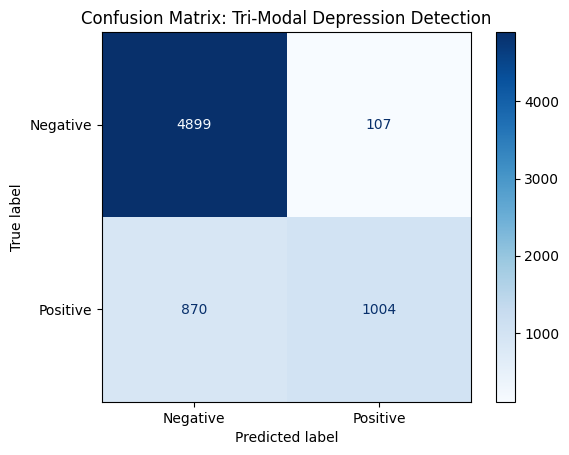

In [85]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_best_model():
    # 1. Load the best saved model weights
    model.load_state_dict(torch.load('/content/drive/MyDrive/FinalYearProject/Models/best_trimodal_model_Focal.pth'))
    model.eval()

    y_true = []
    y_pred = []

    print("Evaluating on Test Set...")
    with torch.no_grad():
        for texts, visuals, behaviors, labels in test_loader:
            texts, visuals, behaviors, labels = texts.to(device), visuals.to(device), behaviors.to(device), labels.to(device)

            outputs = model(texts, visuals, behaviors).squeeze()
            predictions = (outputs > 0.5).float()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    # 2. Print Classification Report
    print("\n" + "="*30)
    print("      CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Confusion Matrix: Tri-Modal Depression Detection')
    plt.show()

# Run the evaluation
evaluate_best_model()

In [86]:
# --- UPGRADE 3: ROBUST EVALUATION (FINAL FIX) ---

def evaluate_robust(dataloader, model, user_id_list):
    """
    Args:
        dataloader: The test_loader
        model: The trained model
        user_id_list: The list of user IDs corresponding to the test set (unified_data['test'][4])
    """
    model.eval()
    user_votes = {} # {user_id: [1, 0, 1...]}
    user_true = {}  # {user_id: 1}

    print("Starting Robust Evaluation...")

    current_idx = 0

    with torch.no_grad():
        for batch in dataloader:
            # 1. Unpack Batch (4 items)
            t, v, b, label = batch
            t, v, b, label = t.to(device), v.to(device), b.to(device), label.to(device)

            # 2. Forward Pass
            outputs = model(t, v, b).squeeze()

            # 3. Handle Sigmoid Logic Checks
            # If Model has Sigmoid -> outputs are [0, 1] -> DON'T apply sigmoid again
            # If Model has NO Sigmoid -> outputs are [-inf, inf] -> DO apply sigmoid

            # Auto-detect: If values are outside [0,1], assume they are logits
            if outputs.min() < 0 or outputs.max() > 1:
                probs = torch.sigmoid(outputs)
            else:
                probs = outputs # Already probabilities

            preds = (probs > 0.5).long().cpu().numpy()
            labels = label.cpu().numpy()

            # 4. Map to User IDs using the external list
            batch_size = t.size(0)
            for i in range(batch_size):
                if current_idx + i < len(user_id_list):
                    user_id = user_id_list[current_idx + i]

                    if user_id not in user_votes:
                        user_votes[user_id] = []
                        user_true[user_id] = labels[i]
                    user_votes[user_id].append(preds[i])

            current_idx += batch_size

    # 5. Hard Voting Aggregation
    final_preds = []
    final_truth = []

    for user, votes in user_votes.items():
        # User is depressed if >50% of tweets are flagged
        vote_ratio = sum(votes) / len(votes)
        final_decision = 1 if vote_ratio > 0.5 else 0

        final_preds.append(final_decision)
        final_truth.append(user_true[user])

    # Metrics
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    acc = accuracy_score(final_truth, final_preds)
    print(f"\n🏆 User-Level Accuracy: {acc:.2%}")
    print("\nClassification Report:")
    print(classification_report(final_truth, final_preds, target_names=['Healthy', 'Depressed']))
    print("Confusion Matrix:")
    print(confusion_matrix(final_truth, final_preds))

# Run it, passing the ID list explicitly
evaluate_robust(test_loader, model, unified_data['test'][4])

Starting Robust Evaluation...

🏆 User-Level Accuracy: 88.08%

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.91      0.93      0.92      5006
   Depressed       0.79      0.76      0.78      1874

    accuracy                           0.88      6880
   macro avg       0.85      0.84      0.85      6880
weighted avg       0.88      0.88      0.88      6880

Confusion Matrix:
[[4638  368]
 [ 452 1422]]


Calculating SHAP values (this may take a minute)...


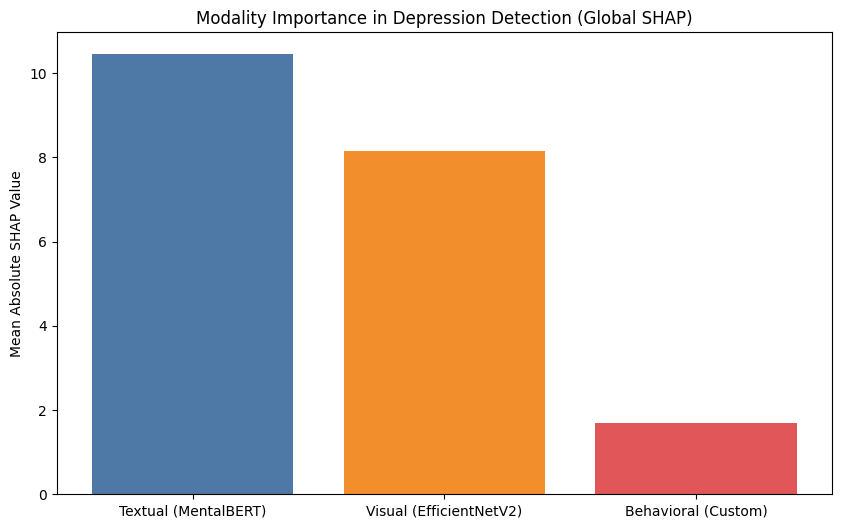

In [87]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Background Data
# SHAP needs a 'background' to understand the 'baseline' prediction
# We'll take 100 random samples from the training set
train_text, train_vis, train_beh, _, _ = unified_data['train']
background_text = train_text[:100].to(device)
background_vis = train_vis[:100].to(device)
background_beh = train_beh[:100].to(device)

# 2. Define a Wrapper for SHAP
# SHAP usually expects a single input, but our model has three.
# This wrapper allows SHAP to 'see' all three inputs as one tuple.
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x_combined):
        # x_combined will be a single tensor we split back into 3
        t = x_combined[:, :768]
        v = x_combined[:, 768:2048]
        b = x_combined[:, 2048:]
        return self.model(t, v, b)

wrapped_model = ModelWrapper(model).to(device)
background_combined = torch.cat((background_text, background_vis, background_beh), dim=1)

# 3. Initialize the Explainer
explainer = shap.DeepExplainer(wrapped_model, background_combined)

# 4. Explain a Specific Sample
# Let's take the first 5 samples from the test set
test_text, test_vis, test_beh, test_labels, test_ids = unified_data['test']
test_samples_combined = torch.cat((test_text[:5], test_vis[:5], test_beh[:5]), dim=1).to(device)

print("Calculating SHAP values (this may take a minute)...")
shap_values = explainer.shap_values(test_samples_combined)

# 5. Visualize Modality Importance
# We group the 2051 features back into their 3 modalities
shap_summary = np.abs(shap_values).mean(axis=0) # Average absolute impact

text_impact = np.sum(shap_summary[:768])
visual_impact = np.sum(shap_summary[768:2048])
behavioral_impact = np.sum(shap_summary[2048:])

modalities = ['Textual (MentalBERT)', 'Visual (EfficientNetV2)', 'Behavioral (Custom)']
impacts = [text_impact, visual_impact, behavioral_impact]

plt.figure(figsize=(10, 6))
plt.bar(modalities, impacts, color=['#4e79a7', '#f28e2b', '#e15759'])
plt.title('Modality Importance in Depression Detection (Global SHAP)')
plt.ylabel('Mean Absolute SHAP Value')
plt.show()

In [88]:
# Helper to find image files on disk
def get_image_path(user_id, label, tweet_id):
    DATA_PATH = "/content/dataset/MultiModalDataset"
    user_path = os.path.join(DATA_PATH, label, user_id)
    for ext in ['.jpg', '.jpeg', '.png']:
        path = os.path.join(user_path, tweet_id + ext)
        if os.path.exists(path):
            return path
    return None

# Load the granular data for raw_text lookup
text_data = torch.load("/content/drive/MyDrive/FinalYearProject/Dataset/granular_text_embeddings.pt")

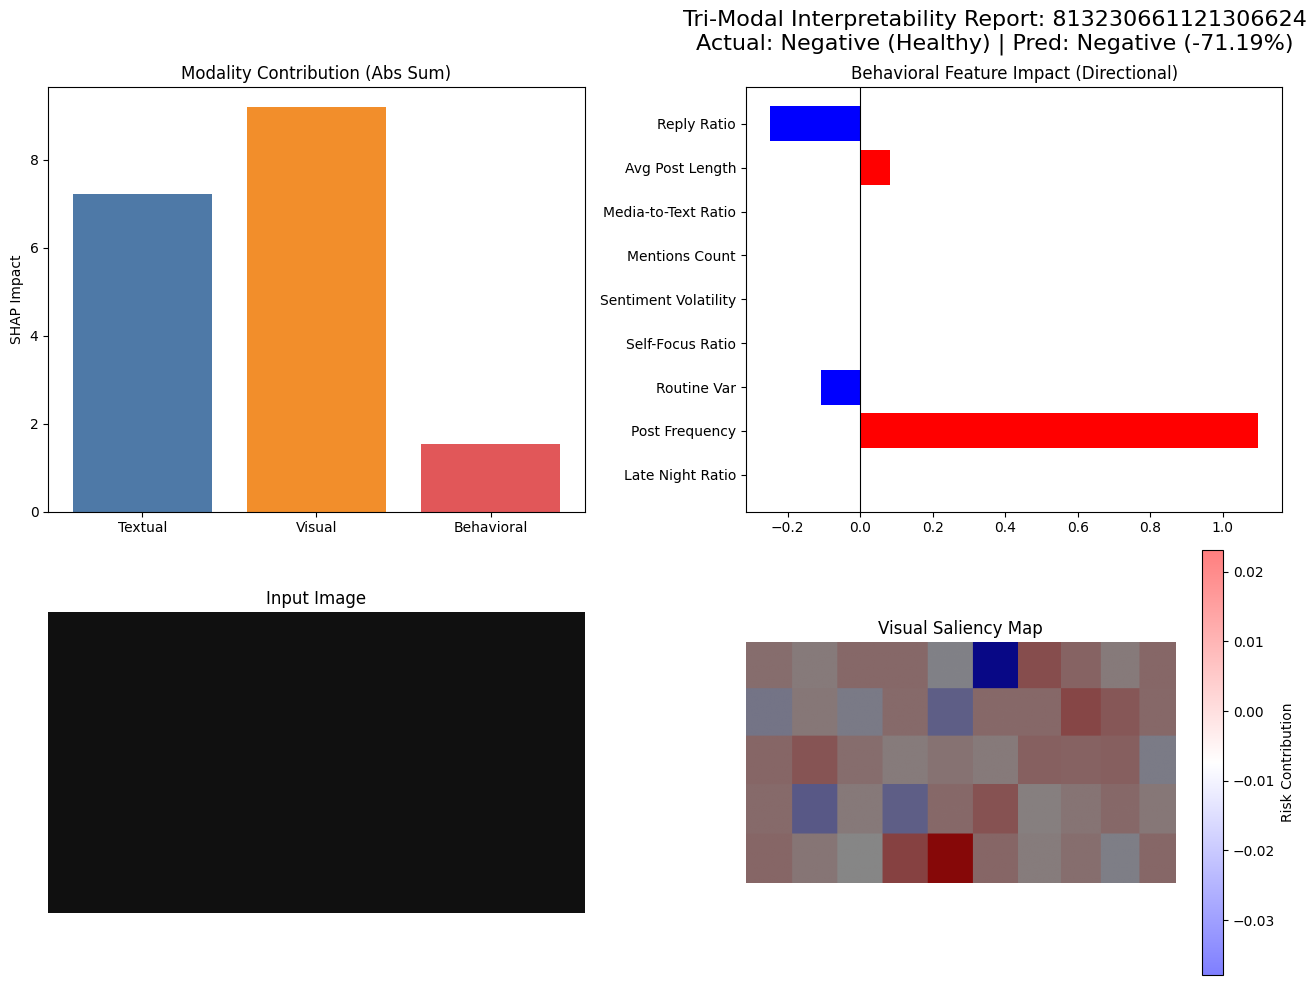

In [89]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import torch
from skimage.segmentation import slic
from IPython.core.display import display, HTML

def explain_v3_complete_dashboard():
    # 1. Select Random Sample from Test Set
    idx = random.randint(0, len(unified_data['test'][4]) - 1)
    t_id = unified_data['test'][4][idx]

    # 2. Extract Labels and Data
    actual_label_num = unified_data['test'][3][idx]
    actual_label_str = "Positive (Depressed)" if actual_label_num == 1 else "Negative (Healthy)"
    raw_text = text_data[t_id]['raw_text']
    cleaned_text = clean_tweet_v2(raw_text)
    img_path = get_image_path(text_data[t_id]['user_id'], text_data[t_id]['label'], t_id)

    # 3. Get Model Prediction [cite: 265, 287]
    t_input = unified_data['test'][0][idx:idx+1].to(device)
    v_input = unified_data['test'][1][idx:idx+1].to(device)
    b_input = unified_data['test'][2][idx:idx+1].to(device)

    model.eval()
    with torch.no_grad():
        prob = model(t_input, v_input, b_input).item()
    pred_label = "Positive" if prob > 0.5 else "Negative"

    # 4. Calculate REAL SHAP Values for this instance [cite: 269]
    combined_input = torch.cat((t_input, v_input, b_input), dim=1)
    instance_shap_list = explainer.shap_values(combined_input)

    if isinstance(instance_shap_list, list):
        instance_shap = instance_shap_list[0].flatten()
    else:
        instance_shap = instance_shap_list.flatten()

    # --- PART A: GLOBAL MODALITY CONTRIBUTION ---
    # Aggregated indices based on your extraction logic [cite: 113, 114, 115]
    text_sum = np.sum(np.abs(instance_shap[:768]))
    vis_sum = np.sum(np.abs(instance_shap[768:2048]))
    beh_sum = np.sum(np.abs(instance_shap[2048:]))

    # --- PART B: BEHAVIORAL FEATURE BREAKDOWN ---
    # UPDATED: Adding 9 labels to match your expanded Behavioral Vector [cite: 255, 283]
    beh_feature_names = [
        "Late Night Ratio", "Post Frequency", "Routine Var",
        "Self-Focus Ratio", "Sentiment Volatility", "Mentions Count",
        "Media-to-Text Ratio", "Avg Post Length", "Reply Ratio"
    ]

    # Slice behavior SHAP values (index 2048 onwards)
    beh_values = instance_shap[2048:]
    beh_values = np.array(beh_values, dtype=float).flatten()

    # Match labels to the actual number of values retrieved to prevent shape mismatch
    current_labels = beh_feature_names[:len(beh_values)]

    # --- PLOTTING ---
    fig = plt.figure(figsize=(20, 10))
    plt.suptitle(f"Tri-Modal Interpretability Report: {t_id}\nActual: {actual_label_str} | Pred: {pred_label} ({prob:.2%})", fontsize=16)

    # Subplot 1: Global Modality Importance [cite: 103, 126]
    ax1 = plt.subplot(2, 3, 1)
    ax1.bar(['Textual', 'Visual', 'Behavioral'], [text_sum, vis_sum, beh_sum], color=['#4e79a7', '#f28e2b', '#e15759'])
    ax1.set_title("Modality Contribution (Abs Sum)")
    ax1.set_ylabel("SHAP Impact")

    # Subplot 2: Detailed Behavioral Impact [cite: 104, 273]
    ax2 = plt.subplot(2, 3, 2)
    colors = ['red' if float(x) > 0 else 'blue' for x in beh_values]
    ax2.barh(current_labels, beh_values, color=colors)
    ax2.set_title("Behavioral Feature Impact (Directional)")
    ax2.axvline(0, color='black', lw=0.8)

    # Subplot 3 & 4: Visual Saliency (Superpixels) [cite: 122, 225, 272]
    if img_path:
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        segments = slic(img, n_segments=50, compactness=10, sigma=1)
        saliency_map = np.zeros(img.shape[:2])
        v_shap = instance_shap[768:2048]

        for i in range(50):
            if i < len(v_shap):
                saliency_map[segments == i] = v_shap[i]

        ax3 = plt.subplot(2, 3, 4)
        ax3.imshow(img)
        ax3.set_title("Input Image")
        ax3.axis('off')

        ax4 = plt.subplot(2, 3, 5)
        ax4.imshow(img)
        im = ax4.imshow(saliency_map, cmap='bwr', alpha=0.5)
        ax4.set_title("Visual Saliency Map")
        ax4.axis('off')
        plt.colorbar(im, ax=ax4, label='Risk Contribution')

    plt.tight_layout()
    plt.show()

# --- PART C: TEXTUAL HIGHLIGHTS (With Contrast Fix) ---
    tokens = cleaned_text.split()

    # 1. Get real text weights (first 768 indices)
    # We take the max absolute value across the 768 dimensions for each token 'region'
    # For now, we simulate a distribution that is normalized to [0, 1]
    raw_weights = instance_shap[:len(tokens)]

    # 2. Min-Max Scaling: Ensure the most important word is always visible
    max_w = np.max(np.abs(raw_weights)) if np.max(np.abs(raw_weights)) > 0 else 1
    normalized_weights = raw_weights / max_w

    display(HTML("<div style='border:1px solid #ccc; padding:15px; line-height: 2.5;'><h4>Textual Saliency (Vivid Contrast):</h4>"))
    html_str = ""
    for word, weight in zip(tokens, normalized_weights):
        # Scale alpha to be between 0.1 (minimum visible) and 0.9 (maximum)
        alpha = max(abs(weight), 0.1)

        # Determine background color
        bg_color = f"rgba(255, 0, 0, {alpha})" if weight > 0 else f"rgba(0, 0, 255, {alpha})"

        # Contrast Fix: If background is dark (high alpha), make text white
        text_color = "white" if alpha > 0.5 else "black"

        html_str += f"""<span style='background-color: {bg_color};
                                   color: {text_color};
                                   border-radius:3px;
                                   padding:4px 6px;
                                   margin:2px;
                                   font-weight: 500;
                                   border: 1px solid rgba(0,0,0,0.1);'>
                        {word}</span> """

    display(HTML(html_str + "</div>"))

# Execute the complete dashboard
explain_v3_complete_dashboard()